In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
import umap
from sklearn.cluster import MiniBatchKMeans

from pathlib import Path

/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ROOT = Path.cwd().parent

In [4]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

In [5]:

data_path = (
    ROOT
    / "data"
    / "gold"
    / "model=nvidia-llama-nemotron-embed-vl-1b-v2"
    / "source=iem_afos"
    / "embeddings.parquet"
)

df = pd.read_parquet(data_path)

### Pre Proccessing

In [6]:
embedding_col = "embedding"

X = np.vstack(df[embedding_col].to_numpy())

In [12]:
X

array([[ 0.00976562,  0.01843262,  0.01757812, ..., -0.01092529,
        -0.02661133, -0.01721191],
       [-0.01940918, -0.00221252,  0.02099609, ..., -0.01208496,
        -0.01977539, -0.00680542],
       [ 0.01330566,  0.03051758, -0.00015926, ..., -0.02380371,
        -0.02563477,  0.00146484],
       ...,
       [ 0.03271484,  0.03320312,  0.01196289, ...,  0.00692749,
        -0.03955078,  0.05200195],
       [ 0.02404785,  0.01379395,  0.00185394, ...,  0.00387573,
        -0.02868652,  0.01940918],
       [ 0.02124023,  0.02038574,  0.0123291 , ...,  0.00860596,
        -0.05712891,  0.01818848]], shape=(34888, 2048))

In [10]:
print(len(X[0]))

2048


### PCA Projection

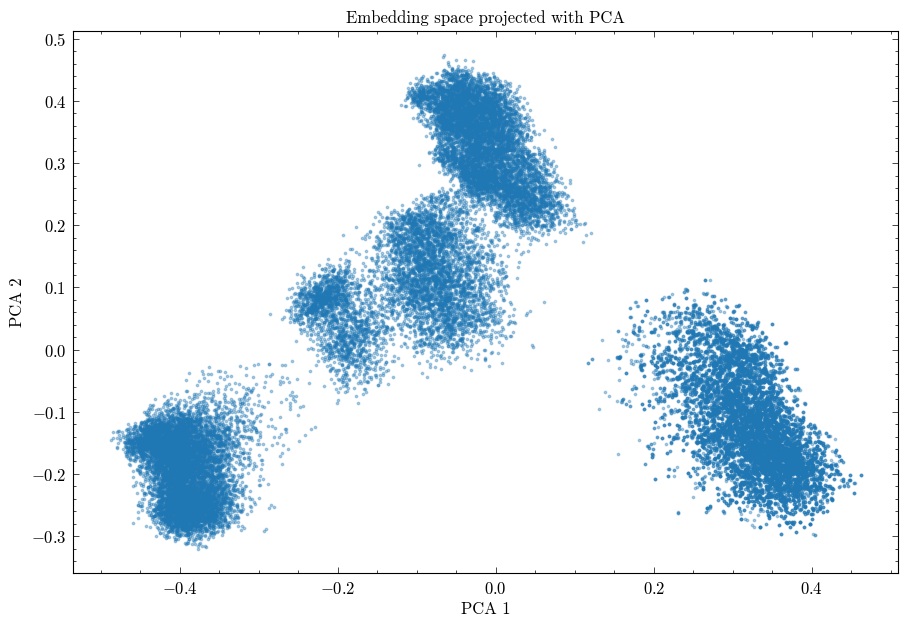

In [7]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

df["pca_x"] = coords[:, 0]
df["pca_y"] = coords[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(
    df["pca_x"],
    df["pca_y"],
    s=3,
    alpha=0.35
)
plt.title("Embedding space projected with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### U Map Projection

In [8]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

coords = reducer.fit_transform(X)

df["umap_x"] = coords[:, 0]
df["umap_y"] = coords[:, 1]

/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely d

KeyboardInterrupt: 

### Clustering

In [ ]:

inertias = []

for k in range(2, 50):
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X)
    inertias.append(km.inertia_)


In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(range(2, 50), inertias)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = MiniBatchKMeans(
    n_clusters=12,
    random_state=42,
    batch_size=4096
)

df["cluster"] = kmeans.fit_predict(X)

In [ ]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    plt.scatter(
        subset["pca_x"],
        subset["pca_y"],
        s=3,
        alpha=0.35,
        label=str(cluster_id)
    )

plt.title("Embedding clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
cluster_counts = (
        df["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )

plt.figure(figsize=(10, 5))
plt.bar(cluster_counts["cluster"].astype(str), cluster_counts["count"])
plt.title("Embedding cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Record count")
plt.show()

### Interactive Clustering

In [ ]:
df.columns

In [ ]:
for idx, metadata in df["metadata"].items():
    if (
        isinstance(metadata, dict)
        and metadata.get("key_messages")
    ):
        print(f"Index: {idx}")
        from pprint import pprint
        pprint(metadata)
        break

In [ ]:
import html
import textwrap
import plotly.express as px

plot_df = df.copy()

# Optional: keep only rows with usable key messages
# plot_df = plot_df[
#     plot_df["metadata"].apply(
#         lambda m: (
#             isinstance(m, dict)
#             and m.get("key_messages") is not None
#             and str(m.get("key_messages")).strip()
#             and str(m.get("key_messages")).lower() != "none"
#         )
#     )
# ].copy()

def format_key_messages(metadata, max_lines=6, width=80):
    if not isinstance(metadata, dict):
        return "No key messages found"

    key_messages = metadata.get("key_messages", "")

    if isinstance(key_messages, list):
        text = "\n".join(str(msg) for msg in key_messages)
    else:
        text = str(key_messages)

    lines = [line.strip() for line in text.splitlines() if line.strip()]

    if not lines:
        return "No key messages found"

    wrapped_lines = []
    for line in lines[:max_lines]:
        safe_line = html.escape(line)
        wrapped_lines.extend(textwrap.wrap(safe_line, width=width))

    return "<br>".join(wrapped_lines)

def build_hover(row):
    title = html.escape(str(row.get("title", "")))
    key_messages = format_key_messages(row.get("metadata", {}))
    cluster = html.escape(str(row.get("cluster", "")))

    return (
        f"<b>{title}</b>"
        f"<br><br><b>Cluster:</b> {cluster}"
        f"<br><br>{key_messages}"
    )

plot_df["hover"] = plot_df.apply(build_hover, axis=1)

def make_embedding_plot(plot_df, x_col, y_col, title, x_label, y_label):
    fig = px.scatter(
        plot_df,
        x=x_col,
        y=y_col,
        color=plot_df["cluster"].astype(str),
        template="plotly_white",
        opacity=0.5,
    )

    fig.update_traces(
        marker=dict(size=5),
        customdata=plot_df["hover"],
        hovertemplate="%{customdata}<extra></extra>",
    )

    fig.update_layout(
        title=title,
        xaxis_title=x_label,
        yaxis_title=y_label,
        legend_title="Cluster",
        width=1100,
        height=750,
        hoverlabel=dict(
            bgcolor="white",
            font_size=13,
            font_family="Arial",
            align="left",
        ),
    )

    return fig

In [ ]:
fig_pca = make_embedding_plot(
    plot_df=plot_df,
    x_col="pca_x",
    y_col="pca_y",
    title="Embedding PCA Projection by Cluster",
    x_label="PCA 1",
    y_label="PCA 2",
)

# fig_pca.show()

In [ ]:
fig_umap = make_embedding_plot(
    plot_df=plot_df,
    x_col="umap_x",
    y_col="umap_y",
    title="Embedding UMAP Projection by Cluster",
    x_label="UMAP 1",
    y_label="UMAP 2",
)

# fig_umap.show()

In [ ]:
# fig_pca.write_html("embedding_pca_clusters.html")
# fig_umap.write_html("embedding_umap_clusters.html")

### cluster text

In [ ]:
import html
import textwrap
from IPython.display import HTML, display

def extract_key_messages(metadata):
    if not isinstance(metadata, dict):
        return None

    msgs = metadata.get("key_messages")

    if msgs is None:
        return None

    if isinstance(msgs, list):
        msgs = "\n".join(str(m) for m in msgs)

    msgs = str(msgs).strip()

    if not msgs or msgs.lower() == "none":
        return None

    return msgs

def wrap_text(text, width=100):
    return "<br>".join(
        textwrap.wrap(html.escape(str(text)), width=width)
    )

def show_cluster_key_messages(df, n_examples=5):
    rows = []

    for cluster_id, group in df.groupby("cluster"):
        examples = (
            group.assign(
                key_message=group["metadata"].apply(extract_key_messages)
            )
            .dropna(subset=["key_message"])
        )

        examples = examples.sample(
            n=min(20, len(examples)),
            random_state=42
        )

        examples = examples.head(n_examples)

        if examples.empty:
            continue

        cards = ""

        for _, row in examples.iterrows():
            title = wrap_text(row.get("title", ""), width=90)
            msg = wrap_text(row["key_message"], width=110)

            cards += f"""
            <div style="
                border-left: 4px solid #444;
                background: #fafafa;
                padding: 10px 14px;
                margin: 8px 0;
                border-radius: 6px;
            ">
                <div style="font-weight: 600; margin-bottom: 6px;">
                    {title}
                </div>
                <div style="font-size: 13px; line-height: 1.45;">
                    {msg}
                </div>
            </div>
            """

        rows.append(f"""
        <div style="
            border: 1px solid #ddd;
            padding: 16px;
            margin: 16px 0;
            border-radius: 10px;
            background: white;
        ">
            <h3 style="margin-top: 0;">Cluster {cluster_id}</h3>
            <p><b>Documents:</b> {len(group):,}</p>
            {cards}
        </div>
        """)

    display(HTML("".join(rows)))

# show_cluster_key_messages(df, n_examples=5)